# The KKT system of linear MPC: assembly, orderings, regularization, inertia and sensitivities

Linear MPC without inequality constraints is one symmetric indefinite linear system. For
$x_{k+1} = A x_k + B u_k$ and a quadratic cost over a horizon $N$, with the stage-ordered variables
$z = (u_0, x_1, u_1, x_2, \dots, u_{N-1}, x_N)$,

$$
\min_z\ \tfrac12 z^\top H z \quad \text{s.t.}\quad G z = b(x_0)
\qquad\Longleftrightarrow\qquad
\underbrace{\begin{bmatrix} H & G^\top \\ G & 0 \end{bmatrix}}_{K_0}
\begin{bmatrix} z \\ y \end{bmatrix} = \begin{bmatrix} 0 \\ b(x_0) \end{bmatrix},
$$

and an interior-point QP solver solves a regularized version of the same system at every iteration.
This notebook builds that system as a `scaly.SparseMatrix` whose values depend on the model
$(A, B)$, factors it with the generated sparse $LDL^\top$, and uses what the sparse layer gives on
the way:

| Scaly feature | Where |
| --- | --- |
| `SparseMatrix.block` over stages, `from_dense`, `diag`, `identity`, `zeros` to fix a block's size, `add_diagonal` for the regularization | assembly |
| `K + K.tril(-1).T`: the full symmetric matrix from its stored lower triangle | residuals |
| `linalg.analyze(perm=...)` and `SparseLDL(symbolic=...)`: a hand-made stage ordering against natural, RCM, minimum degree, dual-first and random | orderings |
| a factorization of $K_\delta$ with iterative refinement against $K_0$ | regularization |
| `fact.inertia()` and `fact.health(signs=...)` | a convexity certificate |
| `sc.jacobian` and `sc.gradient` through `fact.solve` | the Riccati gain, and $\partial V^\star/\partial A$ |
| `sc.segment_max` over the stored entries, `scale_rows`, `scale_cols` | Ruiz equilibration |

The Riccati recursion, in NumPy, is the reference throughout.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import linalg as sla
from scipy import sparse

import plotstyle
import scaly as sc
from scaly import linalg
from scaly.codegen import write_module

plotstyle.use()
SM = sc.SparseMatrix
GENERATED = Path.cwd().parent / "generated" / "sparse_kkt_mpc"

## Oscillating masses

The standard MPC benchmark: $M$ unit masses in a row, joined to each other and to two walls by unit
springs, pushed by $M - 1$ actuators that each act on a pair of neighbours with equal and opposite
forces. The state is the $M$ positions and $M$ velocities; the discretization is exact for a
zero-order hold, $\left[\begin{smallmatrix} A & B \\ 0 & I\end{smallmatrix}\right] = \exp\!\left(
\left[\begin{smallmatrix} A_c & B_c \\ 0 & 0\end{smallmatrix}\right]\Delta t\right)$. The stage cost
is $x^\top Q x + u^\top R u$ with a heavier terminal weight $Q_N$.

In [2]:
M, N, DT = 4, 20, 0.25
NX, NU = 2 * M, M - 1
NZ, NC = N * (NU + NX), N * NX  # primal variables, equality constraints

springs = 2 * np.eye(M) - np.eye(M, k=1) - np.eye(M, k=-1)
push = np.eye(M, NU) - np.eye(M, NU, k=-1)
A_c = np.block([[np.zeros((M, M)), np.eye(M)], [-springs, np.zeros((M, M))]])
B_c = np.r_[np.zeros((M, NU)), push]
E = sla.expm(np.block([[A_c, B_c], [np.zeros((NU, NX + NU))]]) * DT)
A0, B0 = E[:NX, :NX], E[:NX, NX:]
Q, R, Q_N = np.eye(NX), 0.1 * np.eye(NU), 10.0 * np.eye(NX)
X0 = np.r_[1.0, 0.5, -0.5, 0.25, np.zeros(M)]


def riccati(A, B, q_n=Q_N):
  # Finite-horizon LQR: the first gain and the cost-to-go matrix at stage 0.
  P = q_n
  for _ in range(N):
    gain = np.linalg.solve(R + B.T @ P @ B, B.T @ P @ A)
    P = Q + A.T @ P @ (A - B @ gain)
  return gain, P


GAIN, P0 = riccati(A0, B0)
print(f"{NZ} primal variables, {NC} constraints; the KKT matrix is {NZ + NC} x {NZ + NC}")

220 primal variables, 160 constraints; the KKT matrix is 380 x 380


## Assembly with `block`

$H$ is diagonal here, so `SparseMatrix.diag` of a constant. $G$ is an $N \times 2N$ grid of blocks,
row $k$ holding $-B$ under $u_k$, $I$ under $x_{k+1}$ and $-A$ under $x_k$; `from_dense` turns the
symbolic $A$ and $B$ into sparse matrices (every entry, since they are not constants; a `pattern`
argument would keep fewer). Only the lower triangle of $K_0$ is stored: `block([[H, None], [G, Z]])`.
Its $(2,2)$ block must still say how wide the block column is, which `SM.zeros((NC, NC))` does while
storing nothing. `SparseLDL` needs every diagonal entry stored, and the regularized matrix gets them
from `add_diagonal`:

$$
K_\delta = K_0 - \delta \begin{bmatrix} 0 & 0 \\ 0 & I\end{bmatrix} .
$$

K0: 2076 stored (lower triangle), the symmetric matrix 3932, K_delta 2236


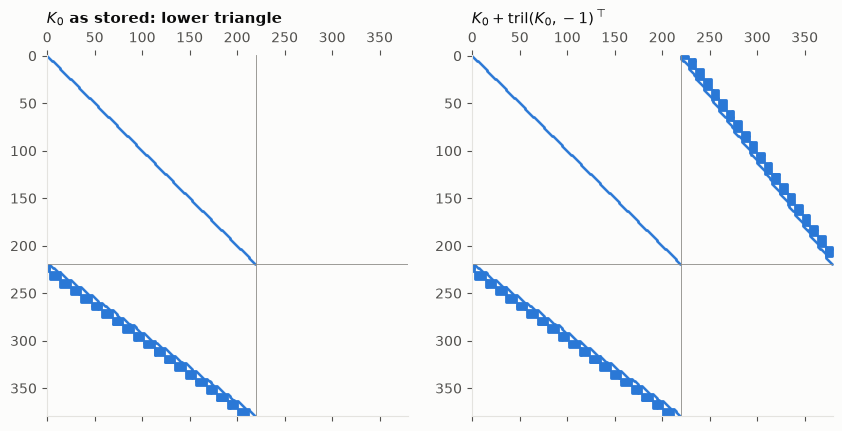

In [3]:
H_DIAG = np.concatenate([np.r_[np.diag(R), np.diag(Q if k < N - 1 else Q_N)] for k in range(N)])
DUALS = np.r_[np.zeros(NZ), np.ones(NC)]


def constraint_matrix(A, B):
  A, B = SM.from_dense(A), SM.from_dense(B)
  grid = [[None] * (2 * N) for _ in range(N)]
  for k in range(N):
    grid[k][2 * k] = -B
    grid[k][2 * k + 1] = SM.identity(NX)
    if k > 0:
      grid[k][2 * k - 1] = -A
  return SM.block(grid)


def kkt_lower(A, B, h_diag=H_DIAG):
  return SM.block([[SM.diag(h_diag), None], [constraint_matrix(A, B), SM.zeros((NC, NC))]])


def rhs(A, x0):
  return sc.concat([sc.const(np.zeros(NZ)), A @ x0, sc.const(np.zeros(NC - NX))])


@sc.function(sc.G(sc.L("A", (NX, NX)), sc.L("B", (NX, NU))), sc.G(sc.S("K0", ...), sc.S("K0_full", ...), sc.S("K_delta", ...)))
def kkt_matrices(inputs):
  K0 = kkt_lower(*inputs)
  return K0, K0 + K0.tril(-1).T, K0.add_diagonal(sc.const(-1e-8 * DUALS))


K0_num, K0_full, K_delta_num = kkt_matrices((A0, B0))
print(f"K0: {K0_num.nnz} stored (lower triangle), the symmetric matrix {K0_full.nnz}, K_delta {K_delta_num.nnz}")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.5, 4.2))
for ax, m, title in ((ax1, K0_num, r"$K_0$ as stored: lower triangle"), (ax2, K0_full, r"$K_0 + \mathrm{tril}(K_0, -1)^\top$")):
  ax.spy(m, markersize=0.8, color=plotstyle.BLUE)
  ax.axhline(NZ - 0.5, color=plotstyle.NEUTRAL, lw=0.6)
  ax.axvline(NZ - 0.5, color=plotstyle.NEUTRAL, lw=0.6)
  ax.set_title(title)
  ax.grid(False)
plt.show()

`K0 @ x` multiplies by the stored entries only, which for a lower triangle is not the symmetric
product; `K0 + K0.tril(-1).T` is the full matrix, with its pattern the union of the two triangles.
The residuals below use it.

## Orderings

Every ordering of a quasi-definite matrix factors without pivoting in exact arithmetic, so the
ordering is chosen for fill alone, and the fill depends a great deal on it:

- **natural** eliminates all of $z$ first. With $H$ diagonal that leaves the Schur complement
  $-G H^{-1} G^\top$, which is block tridiagonal in the stages: little fill.
- **stage** interleaves $(u_k, y_k, x_{k+1})$ stage by stage, the order the Riccati recursion works
  in, a band of width about $2n_x + n_u$. It is passed as `linalg.analyze(..., perm=...)`.
- **rcm** and **mmd** are the two automatic fill-reducing orderings; `ordering="auto"` keeps the
  cheapest of natural, RCM and minimum degree.
- **dual-first** eliminates $y$ first, forming $H + G^\top G/\delta$: the same order of fill, but
  pivots of size $\delta$.
- **random** destroys the band.

In [4]:
STAGE = np.concatenate([np.r_[np.arange(k * (NU + NX), k * (NU + NX) + NU), NZ + k * NX + np.arange(NX), np.arange(k * (NU + NX) + NU, (k + 1) * (NU + NX))] for k in range(N)])
DUAL_FIRST = np.r_[NZ + np.arange(NC), np.arange(NZ)]
RANDOM = np.random.default_rng(0).permutation(NZ + NC)
rows_k, cols_k = SM.from_scipy(K_delta_num).coordinates()
orderings = {
  "natural": dict(method="natural"), "rcm": dict(method="rcm"), "mmd": dict(method="mmd"),
  "stage": dict(perm=STAGE), "dual-first": dict(perm=DUAL_FIRST), "random": dict(perm=RANDOM),
}
analyses = {name: linalg.analyze(K_delta_num.shape, rows_k, cols_k, **kw) for name, kw in orderings.items()}
print(f"{'ordering':11s} {'nnz(L)':>7s} {'multiply-adds':>14s} {'tree height':>12s}")
for name, s in analyses.items():
  st = s.stats()
  print(f"{name:11s} {st['nnz_l']:7d} {st['update_lanes']:14d} {st['height']:12d}")

ordering     nnz(L)  multiply-adds  tree height
natural        3632          20416          161
rcm            3479          19008          310
mmd            3595          20164           92
stage          3536          19328          321
dual-first     4628          32220          221
random        24664        1293012          239


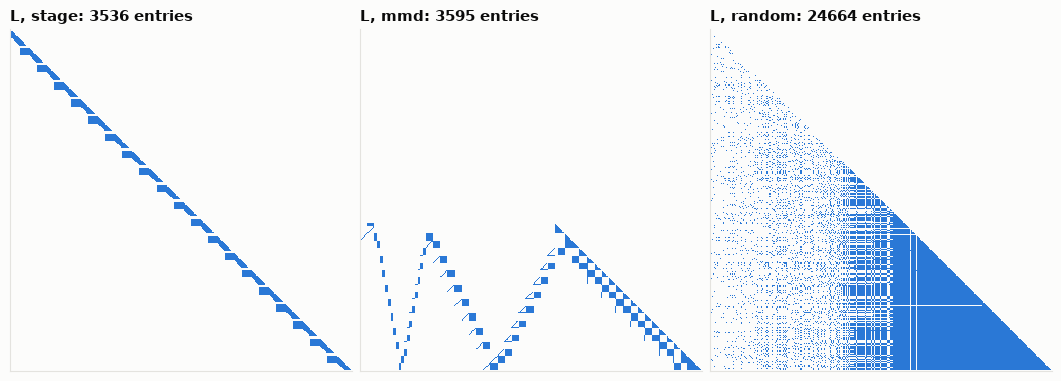

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.8))
for ax, name in zip(axes, ("stage", "mmd", "random")):
  s = analyses[name]
  l_col = np.repeat(np.arange(s.n), np.diff(s.l_ptr))
  ax.plot(l_col, s.l_rows, ",", color=plotstyle.BLUE)
  ax.set_xlim(0, s.n)
  ax.set_ylim(s.n, 0)
  ax.set_aspect("equal")
  ax.grid(False)
  ax.set_xticks([])
  ax.set_yticks([])
  ax.set_title(f"L, {name}: {s.nnz_l} entries")
plt.show()

## One solve against the Riccati recursion

`mpc_step` assembles $K_\delta$ from $(A, B)$, factors it with the stage-ordered analysis and returns
the first input. Unconstrained MPC is finite-horizon LQR, so $u_0 = -K_{\mathrm{LQR}}\, x_0$ and the
optimal cost is $\tfrac12 x_0^\top P_0 x_0$. `inertia()` counts the signs of the pivots: by
Sylvester's law of inertia $(n_z, n_c, 0) = (220, 160, 0)$ exactly when $K_\delta$ has that many
positive and negative eigenvalues.

In [6]:
DELTA = 1e-8
STAGE_ANALYSIS = analyses["stage"]


def solve_kkt(A, B, x0, refine=2, name="mpc"):
  K0 = kkt_lower(A, B)
  fact = linalg.SparseLDL(K0.add_diagonal(sc.const(-DELTA * DUALS)), symbolic=STAGE_ANALYSIS, name=name)
  K0_sym = K0 + K0.tril(-1).T
  b = rhs(A, x0)
  sol = fact.solve(b)
  for _ in range(refine):
    sol = sol + fact.solve(b - K0_sym @ sol)
  z = sol[:NZ]
  cost = 0.5 * sc.dot(z, sc.const(H_DIAG) * z) + 0.5 * sc.dot(x0, sc.const(Q) @ x0)
  return sol, cost, fact


@sc.function(sc.G(sc.L("x0", NX), sc.L("A", (NX, NX)), sc.L("B", (NX, NU))), sc.G(sc.L("u0", NU), sc.L("cost", ()), sc.L("inertia", 3)))
def mpc_step(inputs):
  x0, A, B = inputs
  sol, cost, fact = solve_kkt(A, B, x0)
  return sol[:NU], cost, fact.inertia()


u0, cost, inertia = mpc_step((X0, A0, B0))
print("u0      ", u0, "\n-K x0   ", -GAIN @ X0)
print(f"cost {float(cost):.12f} vs Riccati {0.5 * X0 @ P0 @ X0:.12f};  inertia {inertia}")

u0       [-1.14644226 -0.48117058  0.49720534] 
-K x0    [-1.14644226 -0.48117058  0.49720534]
cost 6.861565091381 vs Riccati 6.861565091381;  inertia [220. 160.   0.]


## Regularize, then refine against the unregularized matrix

$K_0$ is nonsingular here, but in an interior-point method it need not be (dependent constraints,
a singular $H$). Solvers therefore factor $K_\delta$, which is quasi-definite for any $\delta > 0$,
and remove the perturbation by iterative refinement against $K_0$:

$$
s_{j+1} = s_j + K_\delta^{-1}\,(r - K_0 s_j), \qquad s_{j+1} - s^\star = (I - K_\delta^{-1} K_0)(s_j - s^\star),
$$

a contraction whose rate is $O(\delta)$. `fact.solve(b, refine=k)` refines against the factored matrix
itself, which removes rounding error but not the regularization, so `solve_kkt` above writes the loop
against $K_0$: one more solve with the same factor and one product with the symmetric matrix per step.
Below, each $\delta$ gets its own factorization in one `Function`, and the residual
$\lVert r - K_0 s_j\rVert_\infty$ is recorded after every step.

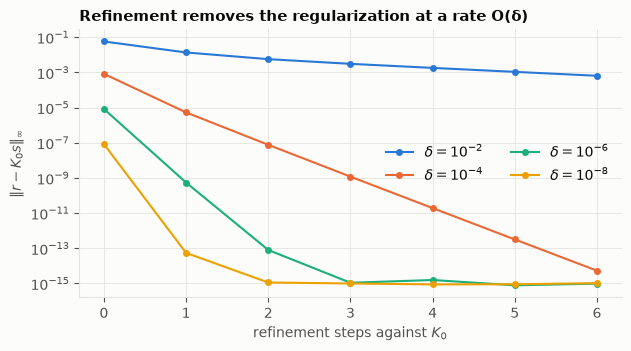

In [7]:
DELTAS, STEPS = (1e-2, 1e-4, 1e-6, 1e-8), 6


@sc.function(sc.G(sc.L("x0", NX), sc.L("A", (NX, NX)), sc.L("B", (NX, NU))), sc.L("residuals", (len(DELTAS), STEPS + 1)))
def refinement(inputs):
  x0, A, B = inputs
  K0 = kkt_lower(A, B)
  K0_sym = K0 + K0.tril(-1).T
  b = rhs(A, x0)
  histories = []
  for i, delta in enumerate(DELTAS):
    fact = linalg.SparseLDL(K0.add_diagonal(sc.const(-delta * DUALS)), symbolic=STAGE_ANALYSIS, name=f"reg{i}")
    sol, history = fact.solve(b), []
    for _ in range(STEPS):
      history.append(sc.norm_inf(b - K0_sym @ sol))
      sol = sol + fact.solve(b - K0_sym @ sol)
    history.append(sc.norm_inf(b - K0_sym @ sol))
    histories.append(sc.stack(history))
  return sc.stack(histories)


residuals = refinement((X0, A0, B0))
fig, ax = plt.subplots(figsize=(6.2, 3.4))
for delta, history in zip(DELTAS, residuals):
  ax.semilogy(np.maximum(history, 1e-17), "o-", ms=4, lw=1.5, label=rf"$\delta = 10^{{{int(np.log10(delta))}}}$")
ax.set_xlabel("refinement steps against $K_0$")
ax.set_ylabel(r"$\|r - K_0 s\|_\infty$")
ax.set_title("Refinement removes the regularization at a rate O(δ)")
ax.legend(ncol=2)
plt.show()

The ordering matters for rounding even though it cannot matter in exact arithmetic. With
$\delta = 10^{-10}$ the dual-first ordering divides by pivots of size $\delta$ first; its unrefined
solution is an order of magnitude further from the Riccati answer than the stage-ordered one, and
one refinement step repairs both:

In [8]:
def first_input_error(perm, delta, refine):
  @sc.function(sc.L("x0", NX), sc.L("u0", NU))
  def step(x0):
    K0 = kkt_lower(sc.const(A0), sc.const(B0))
    K_d = K0.add_diagonal(sc.const(-delta * DUALS))
    fact = linalg.SparseLDL(K_d, symbolic=linalg.analyze(K_d.shape, *K_d.coordinates(), perm=perm), name="order_probe")
    b, K0_sym = rhs(sc.const(A0), x0), K0 + K0.tril(-1).T
    sol = fact.solve(b)
    for _ in range(refine):
      sol = sol + fact.solve(b - K0_sym @ sol)
    return sol[:NU]

  return np.abs(step(X0) + GAIN @ X0).max()


for name, perm in (("stage", STAGE), ("dual-first", DUAL_FIRST)):
  print(f"{name:10s}  |u0 - u0_LQR|: {first_input_error(perm, 1e-10, 0):.1e} unrefined, {first_input_error(perm, 1e-10, 1):.1e} after one step")

stage       |u0 - u0_LQR|: 4.3e-07 unrefined, 6.9e-14 after one step
dual-first  |u0 - u0_LQR|: 3.5e-06 unrefined, 3.7e-12 after one step


## Inertia as a convexity certificate

Make the terminal weight on the first mass's position negative, $Q_N[0,0] = q$. The QP stays strictly
convex as long as the reduced Hessian on the null space of $G$ is positive definite, which is
exactly when $K_0$ has inertia $(n_z, n_c, 0)$ [Gould 1985]. Eliminating the states gives that reduced
Hessian explicitly, $\Gamma^\top \bar Q \Gamma + \bar R$ in the inputs, whose smallest eigenvalue is
the NumPy check. `inertia()` needs no such elimination and runs next to the factorization in the
generated code.

`health(signs=...)` asks something else: that every pivot has the sign of its row's block, the
pattern of a quasi-definite matrix. What that tests depends on the ordering. The natural ordering
eliminates $H$ first, so the pivot of $x_N[0]$ is $q$ itself and the check fails as soon as $q < 0$,
while the QP is still convex. In the stage ordering that pivot comes after the constraints coupling
$x_N$ to the inputs, as a Schur complement, and the check fails exactly when the inertia does. The
inertia itself does not depend on the ordering.

inertia agrees with the reduced Hessian at every q: True
convexity lost between q = -7.5 and -8.0
pivot signs as expected, stage ordering:   exactly while convex
pivot signs as expected, natural ordering: exactly for q > 0


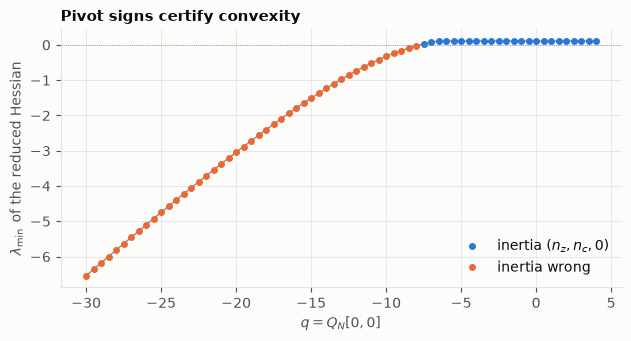

In [9]:
SIGNS = np.where(DUALS > 0, -1.0, 1.0)


@sc.function(sc.L("q", ()), sc.G(sc.L("inertia", 3), sc.L("signs_stage", ...), sc.L("signs_natural", ...)))
def certificate(q):
  h = sc.concat([sc.const(H_DIAG[: NZ - NX]), q.reshape((1,)), sc.const(H_DIAG[NZ - NX + 1 :])])
  K = kkt_lower(sc.const(A0), sc.const(B0), h).add_diagonal(sc.const(-DELTA * DUALS))
  stage = linalg.SparseLDL(K, symbolic=STAGE_ANALYSIS, name="certificate")
  natural = linalg.SparseLDL(K, ordering="natural", name="certificate_natural")
  return stage.inertia(), stage.health(signs=SIGNS), natural.health(signs=SIGNS)


def reduced_hessian_min_eig(q):
  q_n = Q_N.copy()
  q_n[0, 0] = q
  gamma = np.zeros((N * NX, N * NU))  # x_{k+1} = sum_j A^{k-j} B u_j
  for k in range(N):
    for j in range(k + 1):
      gamma[k * NX : (k + 1) * NX, j * NU : (j + 1) * NU] = np.linalg.matrix_power(A0, k - j) @ B0
  q_bar = sla.block_diag(*([Q] * (N - 1) + [q_n]))
  return np.linalg.eigvalsh(gamma.T @ q_bar @ gamma + np.kron(np.eye(N), R)).min()


qs = np.linspace(4, -30, 69)
certs = [certificate(np.array(q)) for q in qs]
convex_by_inertia = np.array([np.array_equal(c[0], [NZ, NC, 0]) for c in certs])
lam_min = np.array([reduced_hessian_min_eig(q) for q in qs])
print("inertia agrees with the reduced Hessian at every q:", np.array_equal(convex_by_inertia, lam_min > 0))
print(f"convexity lost between q = {qs[convex_by_inertia][-1]:.1f} and {qs[~convex_by_inertia][0]:.1f}")
print("pivot signs as expected, stage ordering:  ", "exactly while convex" if np.array_equal([bool(c[1]) for c in certs], convex_by_inertia) else "differs")
print("pivot signs as expected, natural ordering:", "exactly for q > 0" if np.array_equal([bool(c[2]) for c in certs], qs > 0) else "differs")
fig, ax = plt.subplots(figsize=(6.2, 3.3))
ax.plot(qs, lam_min, color=plotstyle.NEUTRAL, lw=1)
ax.plot(qs[convex_by_inertia], lam_min[convex_by_inertia], "o", ms=4, color=plotstyle.BLUE, label=r"inertia $(n_z, n_c, 0)$")
ax.plot(qs[~convex_by_inertia], lam_min[~convex_by_inertia], "o", ms=4, color=plotstyle.ORANGE, label="inertia wrong")
ax.axhline(0, color=plotstyle.NEUTRAL, lw=0.6, ls=":")
ax.set_xlabel(r"$q = Q_N[0, 0]$")
ax.set_ylabel(r"$\lambda_{\min}$ of the reduced Hessian")
ax.set_title("Pivot signs certify convexity")
ax.legend()
plt.show()

## Sensitivities through the factorization

The solve carries its implicit derivative, $\mathrm d s = K^{-1}(\mathrm d r - \mathrm d K\, s)$, so
derivatives of anything computed from the solution come out of `sc.jacobian` and `sc.gradient`
without differentiating the factorization loops:

- $\partial u_0 / \partial x_0$ is minus the finite-horizon LQR gain.
- $\partial V^\star / \partial A$, the optimal cost's sensitivity to the model, by reverse mode: one
  transposed solve. The envelope theorem gives it from the multipliers,
  $\partial V^\star/\partial A = -\sum_{k=0}^{N-1} y_k\, x_k^\top$ with $x_0$ the initial state,
  and a central difference checks one direction.

In [10]:
@sc.function(sc.G(sc.L("x0", NX), sc.L("A", (NX, NX)), sc.L("B", (NX, NU))), sc.G(sc.L("du0_dx0", (NU, NX)), sc.L("dV_dA", (NX, NX)), sc.L("cost", ()), sc.L("solution", NZ + NC)))
def sensitivities(inputs):
  x0, A, B = inputs
  sol, cost, _ = solve_kkt(A, B, x0, name="sens")
  return sc.jacobian(sol[:NU], x0), sc.gradient(cost, A), cost, sol


du0_dx0, dV_dA, _, solution = sensitivities((X0, A0, B0))
x_before = np.r_[X0, solution[:NZ].reshape(N, NU + NX)[:-1, NU:].ravel()].reshape(N, NX)
envelope = -solution[NZ:].reshape(N, NX).T @ x_before
direction = np.random.default_rng(1).standard_normal((NX, NX))
eps = 1e-6
central = (sensitivities((X0, A0 + eps * direction, B0))[2] - sensitivities((X0, A0 - eps * direction, B0))[2]) / (2 * eps)
print(f"|du0/dx0 + K_LQR|_max = {np.abs(du0_dx0 + GAIN).max():.1e}   (|K_LQR|_max = {np.abs(GAIN).max():.2f})")
print(f"|dV/dA - envelope|_max = {np.abs(dV_dA - envelope).max():.1e}   (|dV/dA|_max = {np.abs(dV_dA).max():.2f})")
print(f"directional derivative {np.sum(dV_dA * direction):.8f} vs central difference {float(central):.8f}")

|du0/dx0 + K_LQR|_max = 1.8e-15   (|K_LQR|_max = 1.88)
|dV/dA - envelope|_max = 1.2e-14   (|dV/dA|_max = 23.91)
directional derivative -101.91517206 vs central difference -101.91517207


### In closed loop

`mpc_step` in a receding horizon, 60 samples: one generated call per sample, the same law as the
LQR gain.

77 µs per MPC step (factor, solve, two refinement steps, from Python)


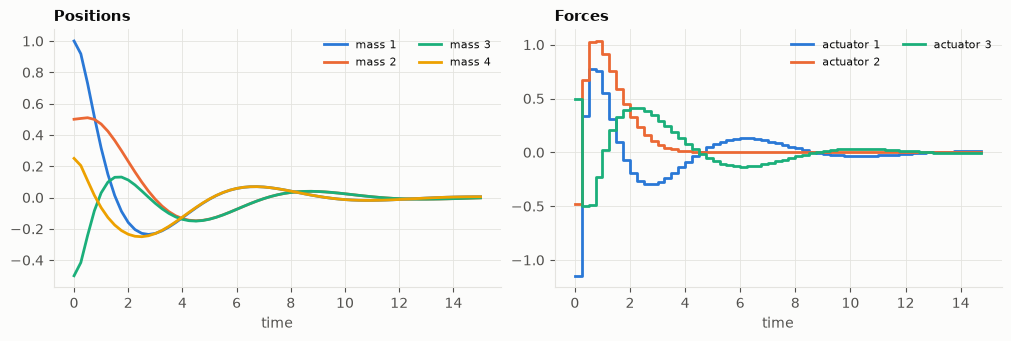

In [11]:
x, xs, us = X0.copy(), [X0], []
start = time.perf_counter()
for _ in range(60):
  u = mpc_step((x, A0, B0))[0]
  x = A0 @ x + B0 @ u
  xs.append(x)
  us.append(u)
elapsed = time.perf_counter() - start
xs, us = np.array(xs), np.array(us)
print(f"{1e6 * elapsed / 60:.0f} µs per MPC step (factor, solve, two refinement steps, from Python)")
t = DT * np.arange(61)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.3))
for i in range(M):
  ax1.plot(t, xs[:, i], label=f"mass {i + 1}")
for i in range(NU):
  ax2.step(t[:-1], us[:, i], where="post", label=f"actuator {i + 1}")
ax1.set_title("Positions")
ax2.set_title("Forces")
for ax in (ax1, ax2):
  ax.set_xlabel("time")
  ax.legend(ncol=2, fontsize=8)
plt.show()

## Ruiz equilibration on the stored entries

Interior-point QP solvers first equilibrate the KKT matrix, $\hat K = D K D$, repeating
$D \leftarrow D\,\mathrm{diag}(\lVert \hat K_{:,j}\rVert_\infty)^{-1/2}$ [Ruiz 2001]. On a
`SparseMatrix` every step is an operation on the values vector with static index tables: the column
maxima of the symmetric matrix are a `segment_max` over the stored lower triangle counted once by
column and once by row, and the scaling is `scale_rows` and `scale_cols`. Everything stays
differentiable, and ten sweeps are ten small straight-line pieces of generated code.

In [12]:
def symmetric_column_max(K):
  rows, cols = K.coordinates()
  v = K.values.abs()
  return sc.segment_max(sc.concat([v, v]), np.r_[cols, rows], K.shape[0])


@sc.function(sc.G(sc.L("A", (NX, NX)), sc.L("B", (NX, NU))), sc.G(sc.S("K", ...), sc.S("K_scaled", ...), sc.L("d", NZ + NC)))
def ruiz(inputs):
  K = kkt_lower(*inputs).add_diagonal(sc.const(-DELTA * DUALS))
  scaled, d = K, sc.const(np.ones(NZ + NC))
  for _ in range(10):
    s = 1.0 / symmetric_column_max(scaled).sqrt()
    scaled, d = scaled.scale_rows(s).scale_cols(s), d * s
  return K, scaled, d


K_num, K_scaled, d = ruiz((A0, B0))


def symmetric(m):
  return (m + sparse.tril(m, -1).T).toarray()


for name, m in (("K_delta", K_num), ("D K_delta D", K_scaled)):
  full = symmetric(m)
  col = np.abs(full).max(axis=0)
  print(f"{name:12s} column max-norms in [{col.min():.3f}, {col.max():.3f}], condition number {np.linalg.cond(full):8.1f}")
print(f"D K D from the generated code equals diag(d) K diag(d): {np.allclose(symmetric(K_scaled), d[:, None] * symmetric(K_num) * d[None, :])}")

K_delta      column max-norms in [0.242, 10.000], condition number   1785.2
D K_delta D  column max-norms in [1.000, 1.000], condition number    548.6
D K D from the generated code equals diag(d) K diag(d): True


## The generated C

`mpc_step` is one C function: the block assembly from $(A, B)$, the factorization in the stage
order, three solves and two products with the symmetric matrix.

In [13]:
module = write_module(mpc_step, GENERATED)
print(f"{module.source_name}: {len(module.source.splitlines())} lines, {len(module.source) / 1e3:.0f} kB, workspace {module.workspace_size} doubles")

mpc_step.c: 485 lines, 436 kB, workspace 14414 doubles


## References

- N. I. M. Gould, "On practical conditions for the existence and uniqueness of solutions to the
  general equality quadratic programming problem," *Mathematical Programming* 32 (1985), 90–99.
  [doi:10.1007/BF01585660](https://doi.org/10.1007/BF01585660)
- D. Ruiz, "A scaling algorithm to equilibrate both rows and columns norms in matrices," Rutherford
  Appleton Laboratory report RAL-TR-2001-034 (2001).
- R. J. Vanderbei, "Symmetric quasidefinite matrices," *SIAM Journal on Optimization* 5 (1995), 100–113.
  [doi:10.1137/0805005](https://doi.org/10.1137/0805005)